# 01 - BCI Data Exploration

This notebook explores the BCI Competition IIIa dataset for motor imagery classification.

## Overview
- **Dataset**: BCI Competition IIIa
- **Task**: 4-class motor imagery classification
- **Classes**: Left (left hand), Right (right hand), Down (foot), Up (tongue)
- **Subjects**: 3 (k3b, k6b, l1b)
- **Channels**: 60 EEG channels
- **Sampling rate**: 250 Hz

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import yaml

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline


## 1. Load Configuration

In [2]:
# Load config
config_path = PROJECT_ROOT / "configs" / "config.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"  Subjects: {config['paths']['subjects']}")
print(f"  Sampling rate: {config['preprocessing']['sfreq']} Hz")
print(f"  Bandpass filter: {config['preprocessing']['bandpass']['low']}-{config['preprocessing']['bandpass']['high']} Hz")
print(f"  Classes: {config['preprocessing']['class_mapping']}")

Configuration loaded:
  Subjects: ['k3b.gdf', 'k6b.gdf', 'l1b.gdf']
  Sampling rate: 250 Hz
  Bandpass filter: 8.0-30.0 Hz
  Classes: {0: 'left', 1: 'right', 2: 'down', 3: 'up'}


## 2. Explore Raw GDF Files

Load and inspect the raw EEG data from GDF files.

In [3]:
# Select subject to explore
subject_file = config['paths']['subjects'][0]  # k3b.gdf
subject_path = PROJECT_ROOT / config['paths']['raw_data'] / subject_file

print(f"Loading: {subject_path}")

# Load raw GDF file
raw = mne.io.read_raw_gdf(subject_path, preload=True, verbose=False)

print(f"\nRaw data loaded:")
print(f"  Channels: {len(raw.ch_names)}")
print(f"  Sampling rate: {raw.info['sfreq']} Hz")
print(f"  Duration: {raw.times[-1]:.2f} seconds")
print(f"  Data points: {raw.n_times}")

Loading: C:\Users\soheil\Downloads\IOS_BCI_STUDIO\bci_ml_pipeline\data\raw\k3b.gdf

Raw data loaded:
  Channels: 60
  Sampling rate: 250.0 Hz
  Duration: 3947.12 seconds
  Data points: 986780


### 2.1 Extract Events

In [4]:
# Extract events from annotations
events, event_id = mne.events_from_annotations(raw, verbose=False)

print(f"Total events: {len(events)}")
print(f"\nEvent types: {event_id}")

# Map event codes to class labels
class_mapping = {
    769: 'Left hand',
    770: 'Right hand',
    771: 'Foot',
    772: 'Tongue'
}

# Count events per class
event_counts = {}
for event_name, event_code in event_id.items():
    for code, label in class_mapping.items():
        if str(code) in event_name:
            count = np.sum(events[:, 2] == event_code)
            event_counts[label] = count

print(f"\nEvent distribution:")
for label, count in event_counts.items():
    print(f"  {label}: {count} trials")

Total events: 1502

Event types: {np.str_('1023'): 1, np.str_('768'): 2, np.str_('769'): 3, np.str_('770'): 4, np.str_('771'): 5, np.str_('772'): 6, np.str_('783'): 7, np.str_('785'): 8, np.str_('786'): 9}

Event distribution:
  Left hand: 45 trials
  Right hand: 45 trials
  Foot: 45 trials
  Tongue: 45 trials


### 2.2 Visualize Event Distribution

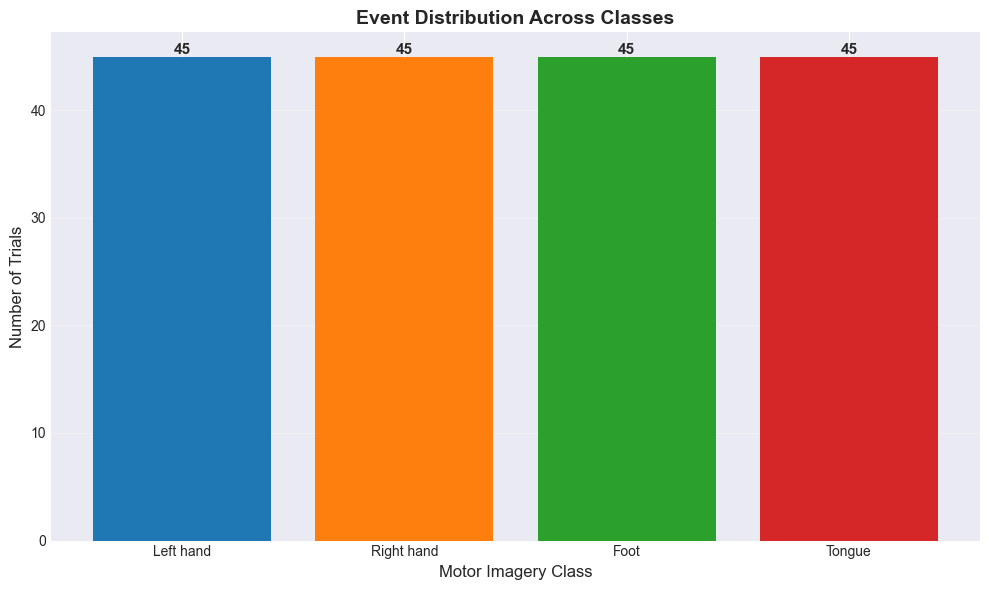

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

classes = list(event_counts.keys())
counts = list(event_counts.values())

bars = ax.bar(classes, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_xlabel('Motor Imagery Class', fontsize=12)
ax.set_ylabel('Number of Trials', fontsize=12)
ax.set_title('Event Distribution Across Classes', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.3 Visualize Raw EEG Signals

Using matplotlib as 2D backend.


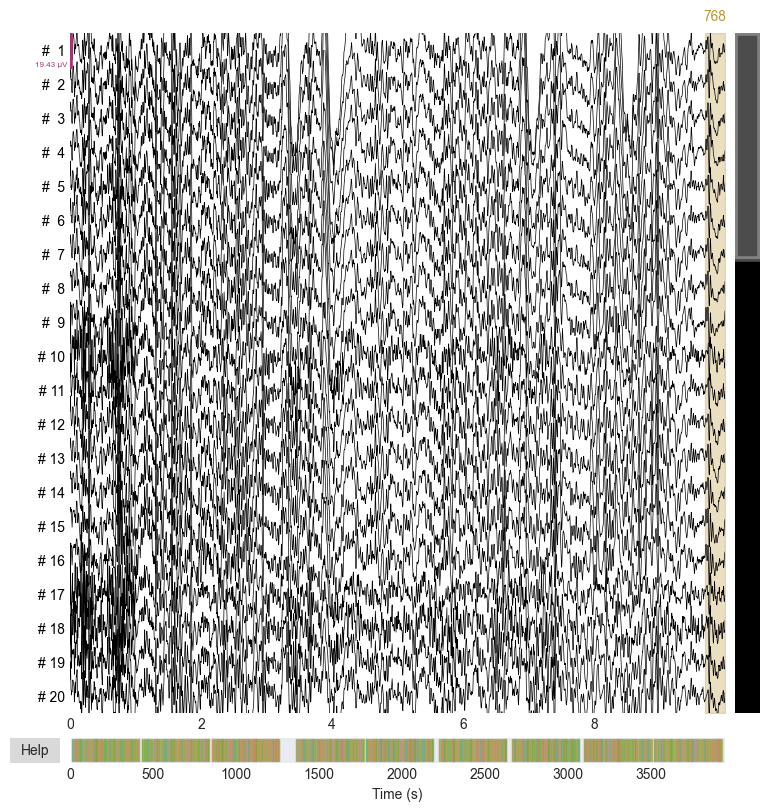

In [6]:
# Plot a segment of raw EEG data
duration = 10  # seconds
start = 0

fig = raw.plot(duration=duration, start=start, n_channels=20, 
               scalings='auto', title='Raw EEG Signals (First 20 Channels)',
               show=False)
plt.show()

### 2.4 Power Spectral Density

Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


C:\Users\soheil\AppData\Local\Temp\ipykernel_37424\3604213160.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


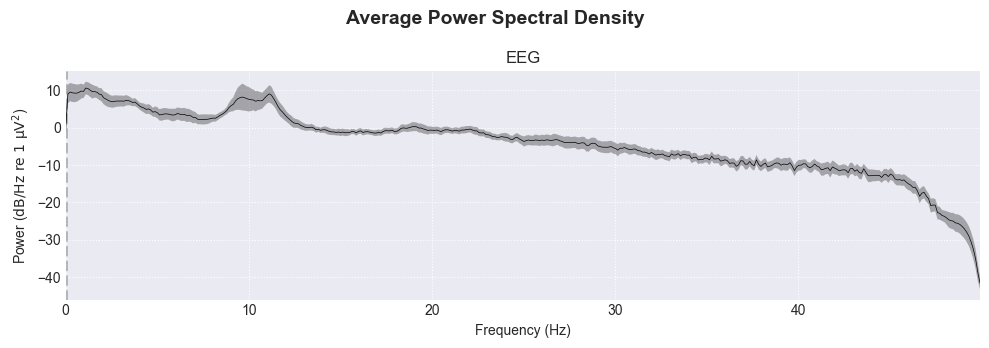

In [7]:
# Compute power spectral density
fig = raw.compute_psd(fmax=50).plot(picks='eeg', average=True, 
                                     show=False)
plt.suptitle('Average Power Spectral Density', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Explore Preprocessed Data

Inspect the preprocessed data that will be used for model training.

In [8]:
# Load preprocessed data
processed_dir = PROJECT_ROOT / config['paths']['processed_data']
subject_id = Path(subject_file).stem

train_file = processed_dir / f"{subject_id}_train.npz"
val_file = processed_dir / f"{subject_id}_val.npz"

if train_file.exists() and val_file.exists():
    train_data = np.load(train_file)
    val_data = np.load(val_file)
    
    X_train = train_data['X']
    y_train = train_data['y']
    X_val = val_data['X']
    y_val = val_data['y']
    
    print("Preprocessed data loaded:")
    print(f"  Training set: {X_train.shape}")
    print(f"    X shape: (n_samples, n_channels, n_timepoints)")
    print(f"    y shape: {y_train.shape}")
    print(f"  Validation set: {X_val.shape}")
    print(f"    y shape: {y_val.shape}")
    
    # Class distribution
    print(f"\nTraining class distribution:")
    unique, counts = np.unique(y_train, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples")
        
    print(f"\nValidation class distribution:")
    unique, counts = np.unique(y_val, return_counts=True)
    for cls, count in zip(unique, counts):
        print(f"  Class {cls}: {count} samples")
else:
    print("Preprocessed data not found.")
    print(f"Run: python scripts/1_preprocess_data.py")

Preprocessed data loaded:
  Training set: (144, 60, 1001)
    X shape: (n_samples, n_channels, n_timepoints)
    y shape: (144,)
  Validation set: (36, 60, 1001)
    y shape: (36,)

Training class distribution:
  Class 0: 36 samples
  Class 1: 36 samples
  Class 2: 36 samples
  Class 3: 36 samples

Validation class distribution:
  Class 0: 9 samples
  Class 1: 9 samples
  Class 2: 9 samples
  Class 3: 9 samples


### 3.1 Visualize Sample Epochs

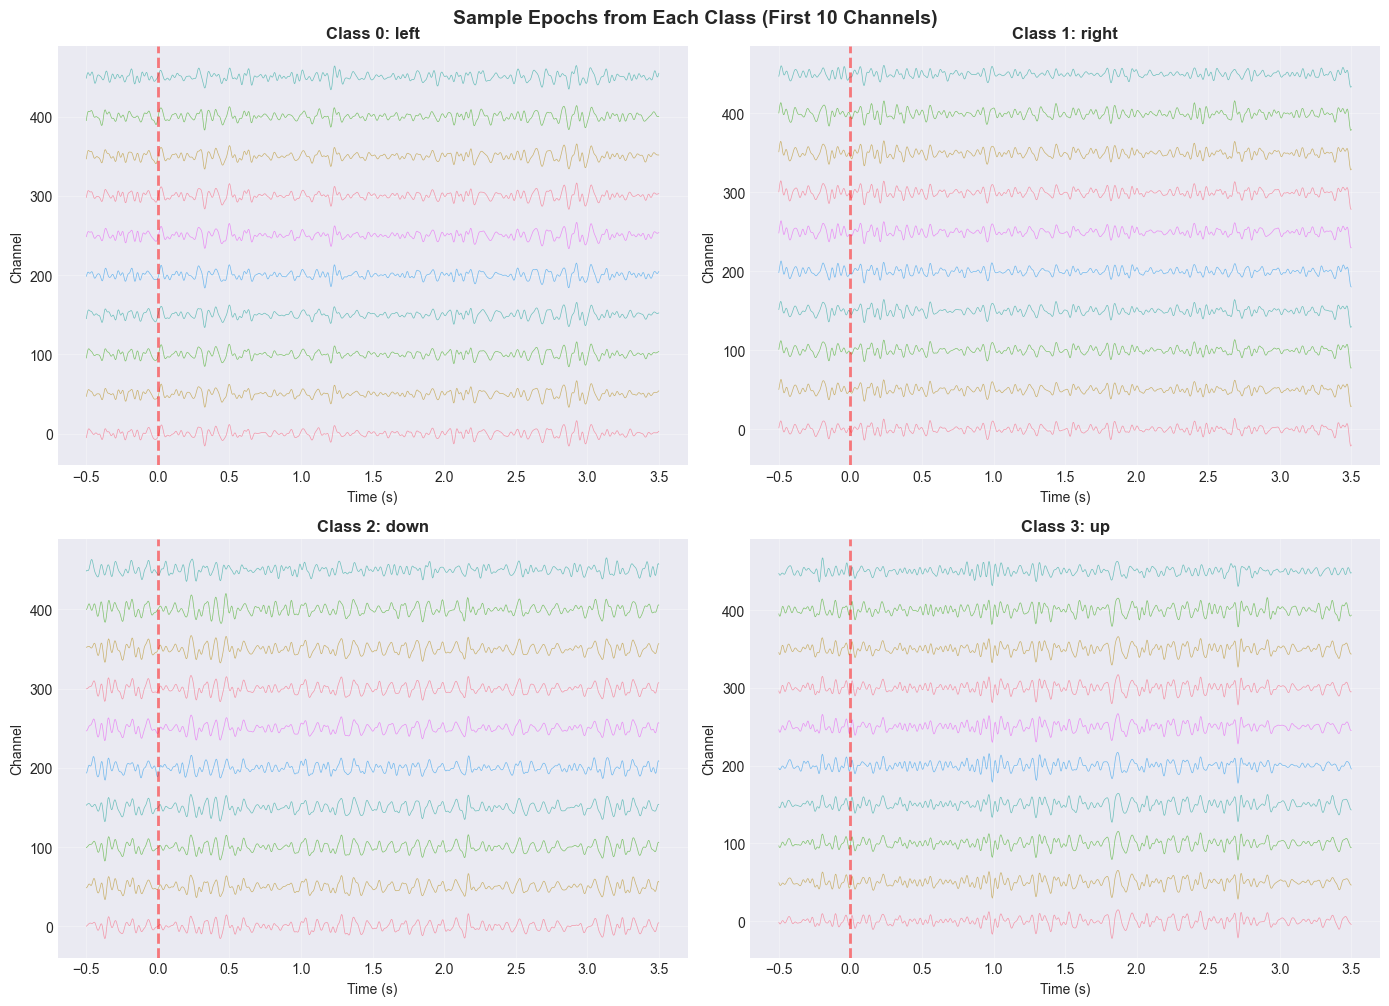

In [9]:
if train_file.exists():
    # Select one sample from each class
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    class_names = config['preprocessing']['class_mapping']
    
    for cls_idx in range(4):
        # Get first sample of this class
        sample_idx = np.where(y_train == cls_idx)[0][0]
        sample = X_train[sample_idx]  # Shape: (n_channels, n_timepoints)
        
        # Plot first 10 channels
        time_axis = np.linspace(config['preprocessing']['epoch']['tmin'],
                                config['preprocessing']['epoch']['tmax'],
                                sample.shape[1])
        
        for ch_idx in range(min(10, sample.shape[0])):
            axes[cls_idx].plot(time_axis, sample[ch_idx, :] + ch_idx * 50, 
                              linewidth=0.5, alpha=0.7)
        
        axes[cls_idx].set_xlabel('Time (s)', fontsize=10)
        axes[cls_idx].set_ylabel('Channel', fontsize=10)
        axes[cls_idx].set_title(f'Class {cls_idx}: {class_names[cls_idx]}', 
                                fontsize=12, fontweight='bold')
        axes[cls_idx].grid(alpha=0.3)
        axes[cls_idx].axvline(x=0, color='red', linestyle='--', linewidth=2, 
                             alpha=0.5, label='Cue onset')
    
    plt.tight_layout()
    plt.suptitle('Sample Epochs from Each Class (First 10 Channels)', 
                 fontsize=14, fontweight='bold', y=1.002)
    plt.show()

### 3.2 Amplitude Statistics

Amplitude statistics (training data):
  Min: -6.14e+01
  Max: 5.93e+01
  Mean: 7.86e-03
  Std: 5.66e+00


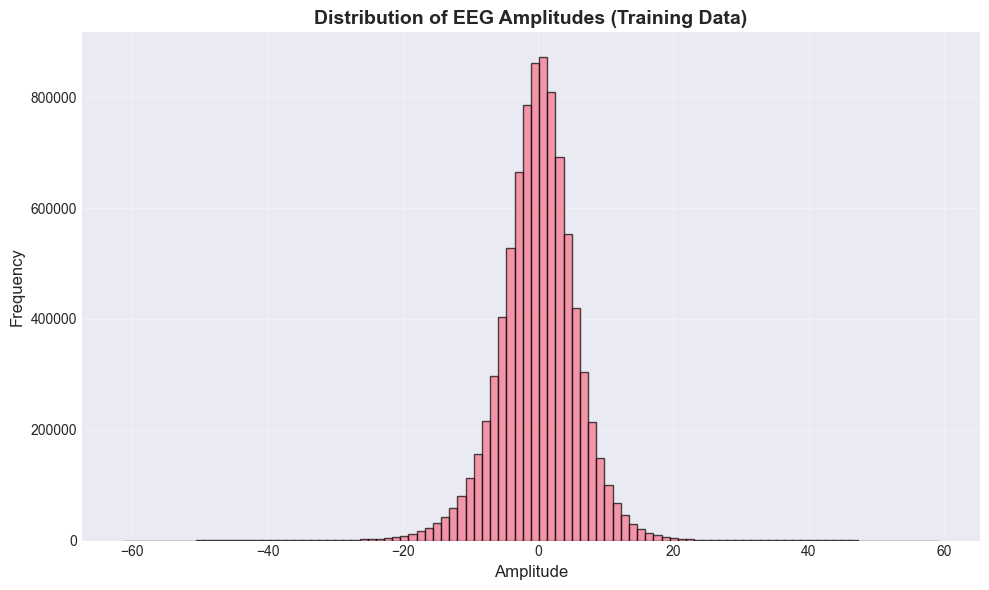

In [10]:
if train_file.exists():
    print("Amplitude statistics (training data):")
    print(f"  Min: {X_train.min():.2e}")
    print(f"  Max: {X_train.max():.2e}")
    print(f"  Mean: {X_train.mean():.2e}")
    print(f"  Std: {X_train.std():.2e}")
    
    # Distribution of amplitudes
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(X_train.flatten(), bins=100, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Amplitude', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of EEG Amplitudes (Training Data)', 
                 fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Summary

Data exploration complete. Key findings:
- Dataset contains 3 subjects with 60 EEG channels
- 4-class motor imagery task: Left (left hand), Right (right hand), Down (foot), Up (tongue)
- Data preprocessed with bandpass filtering (8-30 Hz) and epoching
- Approximately balanced class distribution

**Next step**: Train the EEGNet model using `02_train_model.ipynb`